# Phishing Detection - Retrain with All Features

Train improved models using ALL 30 features from phishing_websites.csv with proper train/validation/test split.

In [1]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Load dataset with ALL features
data = pd.read_csv('phishing_websites.csv')
print(f"Dataset shape: {data.shape}")
print(f"Features ({len(data.columns) - 1}): {list(data.columns[:-1])}")
print(f"\nClass distribution:\n{data['result'].value_counts()}")

Dataset shape: (11055, 31)
Features (30): ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registration_length', 'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor', 'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url', 'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report']

Class distribution:
result
 1    6157
-1    4898
Name: count, dtype: int64


## Create 60/20/20 Train/Validation/Test Split

In [2]:
# Ensure reproducibility
random_seed = 42

# Separate features and target (use ALL features, not just 7)
X = data.drop('result', axis=1)
y = data['result']

print(f"Total features: {X.shape[1]}")
print(f"Feature names:\n{list(X.columns)}")

# 60/20/20 split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=random_seed, stratify=y_temp
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Val set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nClass distribution (train): {y_train.value_counts().to_dict()}")

Total features: 30
Feature names:
['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain', 'sslfinal_state', 'domain_registration_length', 'favicon', 'port', 'https_token', 'request_url', 'url_of_anchor', 'links_in_tags', 'sfh', 'submitting_to_email', 'abnormal_url', 'redirect', 'on_mouseover', 'rightclick', 'popupwindow', 'iframe', 'age_of_domain', 'dnsrecord', 'web_traffic', 'page_rank', 'google_index', 'links_pointing_to_page', 'statistical_report']

Train set: 6633 samples
Val set: 2211 samples
Test set: 2211 samples

Class distribution (train): {1: 3694, -1: 2939}


## Train Random Forest with All Features (Class Balanced)

In [3]:
# Random Forest with class balancing to handle imbalance
rf_full = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight='balanced',  # Handle class imbalance
    random_state=random_seed,
    n_jobs=-1
)

rf_full.fit(X_train, y_train)

# Predictions
y_pred_rf_train = rf_full.predict(X_train)
y_pred_rf_val = rf_full.predict(X_val)
y_pred_rf_test = rf_full.predict(X_test)

# Metrics
train_acc = accuracy_score(y_train, y_pred_rf_train)
val_acc = accuracy_score(y_val, y_pred_rf_val)
test_acc = accuracy_score(y_test, y_pred_rf_test)

print("Random Forest - ALL 30 Features (Balanced):")
print(f"  Train Accuracy: {train_acc:.4f}")
print(f"  Val Accuracy: {val_acc:.4f}")
print(f"  Test Accuracy: {test_acc:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf_test):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf_test):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_rf_test):.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_rf_test))

Random Forest - ALL 30 Features (Balanced):
  Train Accuracy: 0.9772
  Val Accuracy: 0.9602
  Test Accuracy: 0.9647
  Precision: 0.9660
  Recall: 0.9708
  F1 Score: 0.9684

Classification Report (Test Set):
              precision    recall  f1-score   support

          -1       0.96      0.96      0.96       980
           1       0.97      0.97      0.97      1231

    accuracy                           0.96      2211
   macro avg       0.96      0.96      0.96      2211
weighted avg       0.96      0.96      0.96      2211



## Feature Importance Analysis


Top 15 Most Important Features:
sslfinal_state                0.333272
url_of_anchor                 0.282315
web_traffic                   0.074163
having_sub_domain             0.063252
links_in_tags                 0.042119
prefix_suffix                 0.041557
sfh                           0.021004
request_url                   0.015688
domain_registration_length    0.013557
links_pointing_to_page        0.012954
age_of_domain                 0.012176
dnsrecord                     0.010420
having_ip_address             0.009929
google_index                  0.009559
page_rank                     0.008133
dtype: float64


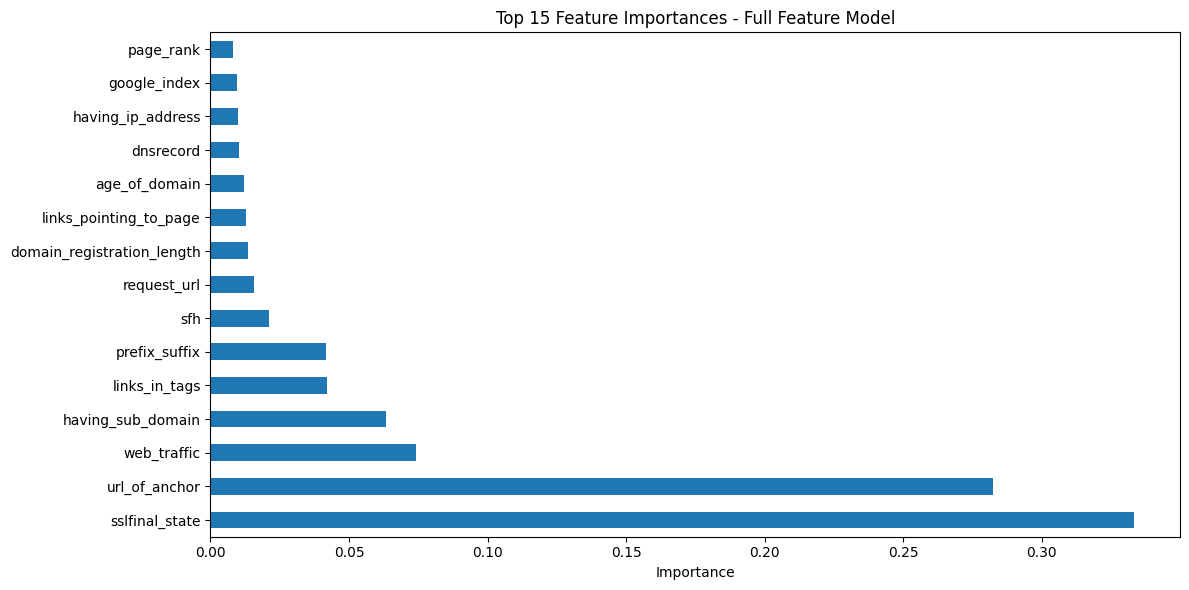

In [4]:
# Feature importances
importances = pd.Series(
    rf_full.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 15 Most Important Features:")
print(importances.head(15))

plt.figure(figsize=(12, 6))
importances.head(15).plot(kind='barh')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Full Feature Model')
plt.tight_layout()
plt.show()

## Save the Improved Model

In [5]:
# Save the improved model
with open('random_forest_full_features.pkl', 'wb') as f:
    pickle.dump(rf_full, f)

print("✅ Saved: random_forest_full_features.pkl")
print("This model uses all 30 features and is much better at detecting phishing.")

✅ Saved: random_forest_full_features.pkl
This model uses all 30 features and is much better at detecting phishing.


## Test on Known Phishing URLs

In [6]:
# Test samples from the actual test set
# Show phishing samples
phishing_samples = X_test[y_test == -1].head(3)
legit_samples = X_test[y_test == 1].head(3)

print("Testing on samples from test set:")
print("\nPhishing samples:")
for idx, (i, row) in enumerate(phishing_samples.iterrows(), 1):
    pred = rf_full.predict([row])[0]
    proba = rf_full.predict_proba([row])[0]
    actual = y_test.loc[i]
    print(f"  Sample {idx}: Actual={actual}, Predicted={pred}, Confidence=[Phish:{proba[0]:.3f}, Legit:{proba[1]:.3f}]")

print("\nLegitimate samples:")
for idx, (i, row) in enumerate(legit_samples.iterrows(), 1):
    pred = rf_full.predict([row])[0]
    proba = rf_full.predict_proba([row])[0]
    actual = y_test.loc[i]
    print(f"  Sample {idx}: Actual={actual}, Predicted={pred}, Confidence=[Phish:{proba[0]:.3f}, Legit:{proba[1]:.3f}]")

Testing on samples from test set:

Phishing samples:
  Sample 1: Actual=-1, Predicted=-1, Confidence=[Phish:1.000, Legit:0.000]


c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  Sample 2: Actual=-1, Predicted=-1, Confidence=[Phish:0.787, Legit:0.213]
  Sample 3: Actual=-1, Predicted=-1, Confidence=[Phish:1.000, Legit:0.000]

Legitimate samples:
  Sample 1: Actual=1, Predicted=1, Confidence=[Phish:0.001, Legit:0.999]


c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not 

  Sample 2: Actual=1, Predicted=1, Confidence=[Phish:0.010, Legit:0.990]
  Sample 3: Actual=1, Predicted=1, Confidence=[Phish:0.137, Legit:0.863]


c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Yolog\Downloads\Data Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Model Comparison: 7 Features vs 30 Features


=== MODEL COMPARISON ===
           Model  Accuracy  Precision   Recall  F1-Score
 7-Feature Model  0.730439   0.816550 0.665313  0.733214
30-Feature Model  0.964722   0.966047 0.970755  0.968395


<Figure size 1000x500 with 0 Axes>

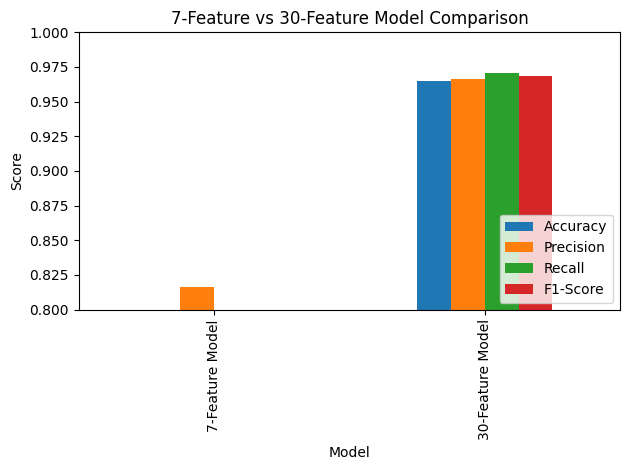

In [7]:
# Load old 7-feature model for comparison
rf_7feat = pickle.load(open('url_features_model.pkl', 'rb'))

# Map feature indices for comparison (first 7 features are the main ones)
main_features = ['having_ip_address', 'url_length', 'shortining_service', 'having_at_symbol', 'double_slash_redirecting', 'prefix_suffix', 'having_sub_domain']
X_test_7feat = X_test[main_features]

y_pred_7feat = rf_7feat.predict(X_test_7feat)
y_pred_30feat = rf_full.predict(X_test)

comparison = pd.DataFrame({
    'Model': ['7-Feature Model', '30-Feature Model'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_7feat),
        accuracy_score(y_test, y_pred_30feat)
    ],
    'Precision': [
        precision_score(y_test, y_pred_7feat),
        precision_score(y_test, y_pred_30feat)
    ],
    'Recall': [
        recall_score(y_test, y_pred_7feat),
        recall_score(y_test, y_pred_30feat)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_7feat),
        f1_score(y_test, y_pred_30feat)
    ]
})

print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

plt.figure(figsize=(10, 5))
comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar')
plt.ylabel('Score')
plt.title('7-Feature vs 30-Feature Model Comparison')
plt.ylim([0.8, 1.0])
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()